# Example of Probable DPA Activation
This notebook is an example of using the [NASCTN CBRS SEA data set](https://data.nist.gov/od/id/mds2-4214) to identify a potential DPA activation. 

## Imports 

In [1]:
import os,sys
sys.path.append(os.path.join(os.getcwd(),"../"))
from nasctn_sea_visualization import *
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import matplotlib.dates as mdates

Importing nasctn_sea_visualization.data_models
It took 1.594058 s to import nasctn_sea_visualization.data_models
Importing nasctn_sea_visualization.plotters


It took 2.653936 s to import nasctn_sea_visualization.plotters
It took 4.247994 s to import all of the active modules


## Data Ingest

In [2]:
# Update path to your copy or https://data.nist.gov/od/ds/mds2-4214/Summaries/2025_03.csv
march_2025_summary = pd.read_csv(r"Y:\Tier2\Summaries\2025_03.csv")

In [3]:
hu_20250328 = DayBlock(file_path =  r"C:\Users\sandersa\Box\SEA-DATA\Raw Data\2025-03-28_HU.zip")

In [4]:
max_psd = hu_20250328.get_day_psd(capture_statistic='max', save=False, save_type='csv')
median_psd = hu_20250328.get_day_psd(capture_statistic='median', save=False, save_type='csv')

In [92]:
channel = 3635e6
pfp_peak_max = hu_20250328.get_aligned_pfp(channel=channel,capture_statistic='max', detector='peak', save=False, save_type='csv')

In [7]:
cbsd_time = pd.to_datetime("2025-03-28 7:30:00",utc = True)
incumbent_time = pd.to_datetime("2025-03-28 10:30:00",utc = True)
noise_time = pd.to_datetime("2025-03-28 12:30:00",utc = True)

In [66]:
cbsd_single = DataProduct(hu_20250328.get_single(cbsd_time))
incumbent_single = DataProduct(hu_20250328.get_single(incumbent_time))
noise_single = DataProduct(hu_20250328.get_single(noise_time))

## Plotting

In [93]:
start_time = pd.to_datetime("2025-03-28 6:00:00",utc = True)
stop_time = pd.to_datetime("2025-03-28 14:00:00",utc = True)
start_frequency = 3550
stop_frequency = 3650

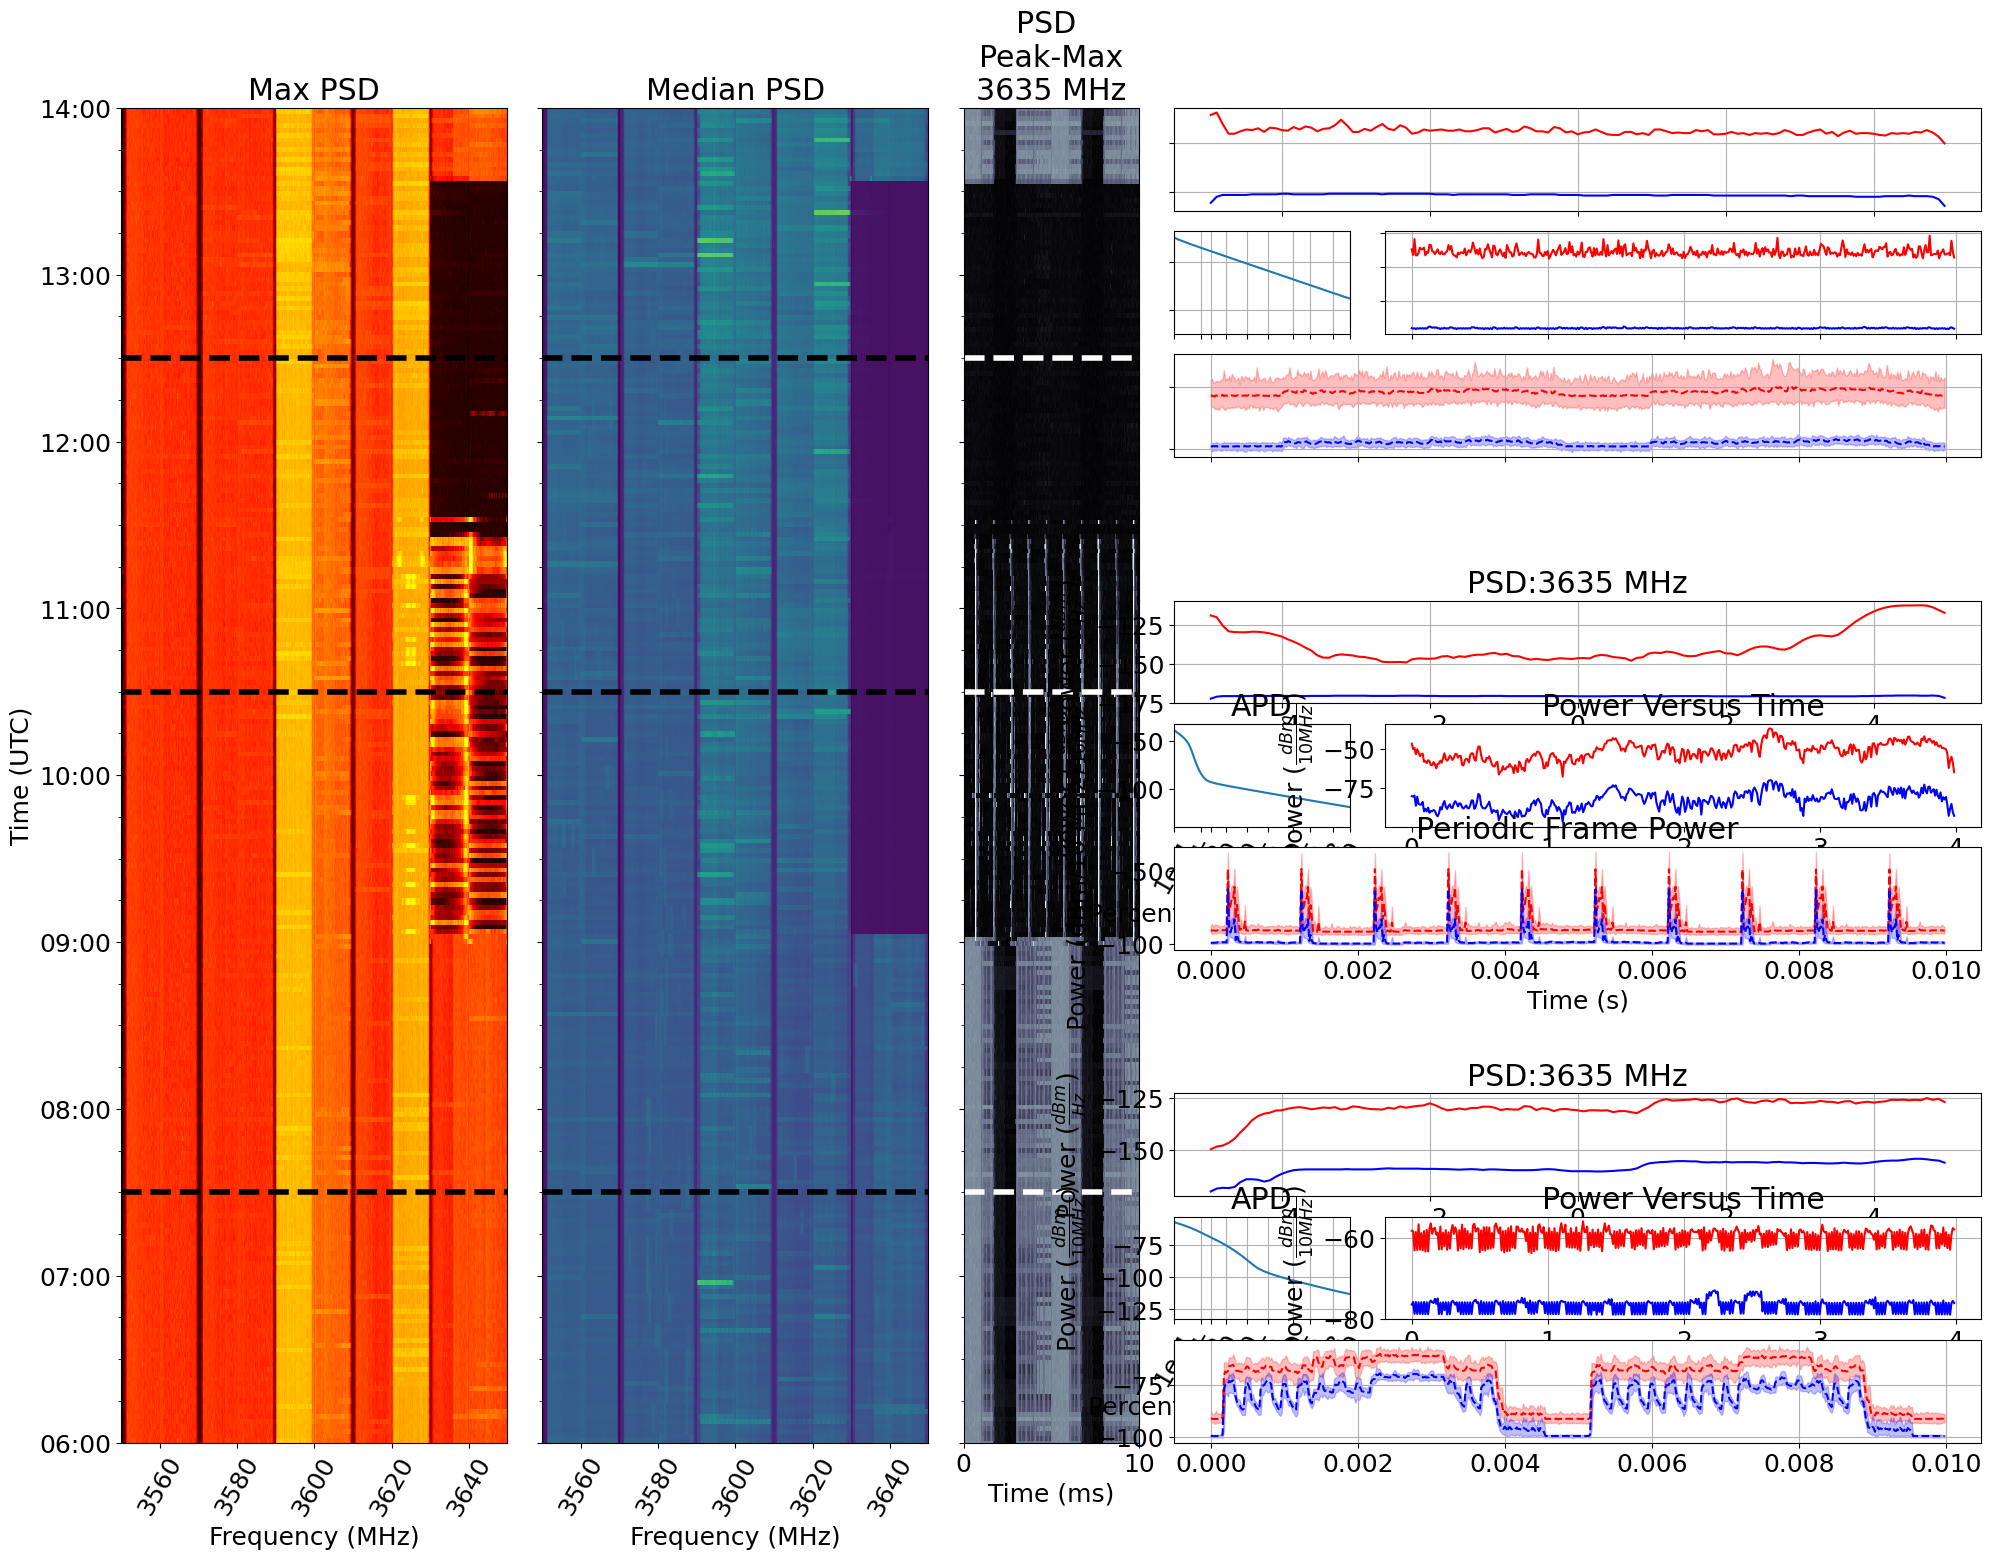

In [113]:

plt.rcParams.update({"font.size":18})
figure = plt.figure(figsize=(72/3,52/3))
# Setup Gridspec
gs = matplotlib.gridspec.GridSpec(11,9)    # Bottom margin
##########################################
psd_max_ax = figure.add_subplot(gs[:,0:2])
psd_median_ax = figure.add_subplot(gs[:,2:4],sharex=psd_max_ax,sharey=psd_max_ax)
pfp_ax = figure.add_subplot(gs[:,4],sharey=psd_max_ax)
#########################################
# noise
psd_summary_1 = figure.add_subplot(gs[0,5:])
apd_summary_1 = figure.add_subplot(gs[1,5:6])
pvt_summary_1 = figure.add_subplot(gs[1,6:])
pfp_summary_1 = figure.add_subplot(gs[2:3,5:])
##########################################
# incumbent
psd_summary_2 = figure.add_subplot(gs[4,5:])
apd_summary_2 = figure.add_subplot(gs[5,5:6])
pvt_summary_2 = figure.add_subplot(gs[5,6:])
pfp_summary_2 = figure.add_subplot(gs[6:7,5:])
##############################################
# cbsd
psd_summary_3 = figure.add_subplot(gs[8,5:])
apd_summary_3 = figure.add_subplot(gs[9,5:6])
pvt_summary_3 = figure.add_subplot(gs[9,6:])
pfp_summary_3 = figure.add_subplot(gs[10:,5:])

###############################################
# Max PSD Axis
colormesh = psd_max_ax.pcolormesh(1e-6*max_psd.columns.astype(float),max_psd.index,max_psd,cmap="hot")
psd_max_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
psd_max_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
psd_max_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
psd_max_ax.set_ylim([start_time,stop_time])
psd_max_ax.set_xlim([start_frequency,stop_frequency])
psd_max_ax.set_title("Max PSD")
psd_max_ax.axhline(cbsd_time,color = "k",linestyle="dashed",linewidth=4)
psd_max_ax.axhline(noise_time,color = "k",linestyle="dashed",linewidth=4)
psd_max_ax.axhline(incumbent_time,color = "k",linestyle="dashed",linewidth=4)
psd_max_ax.tick_params("x",labelbottom=True,rotation=60)
psd_max_ax.set_ylabel("Time (UTC)")
psd_max_ax.set_xlabel("Frequency (MHz)")
##############################################
# Median PSD Axis
colormesh = psd_median_ax.pcolormesh(1e-6*median_psd.columns.astype(float),median_psd.index,median_psd)
psd_median_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
psd_median_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
psd_median_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
psd_median_ax.set_ylim([start_time,stop_time])
psd_median_ax.set_xlim([start_frequency,stop_frequency])
psd_median_ax.set_title("Median PSD")
psd_median_ax.axhline(cbsd_time,color = "k",linestyle="dashed",linewidth=4)
psd_median_ax.axhline(noise_time,color = "k",linestyle="dashed",linewidth=4)
psd_median_ax.axhline(incumbent_time,color = "k",linestyle="dashed",linewidth=4)
psd_median_ax.tick_params("x",labelbottom=True,rotation=60)
psd_median_ax.tick_params("y",labelleft=False)
psd_median_ax.set_xlabel("Frequency (MHz)")
###################################################
# PFP Axis
x_axis = np.linspace(0,10,len(pfp_peak_max.columns))
colormesh = pfp_ax.pcolormesh(x_axis,pfp_peak_max.index,pfp_peak_max,cmap='bone',
                            vmin=np.min(pfp_peak_max.values),vmax=np.max(pfp_peak_max.values))
pfp_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
pfp_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
pfp_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
pfp_ax.tick_params("y",labelleft=False)
pfp_ax.axhline(cbsd_time,color = "w",linestyle="dashed",linewidth=4)
pfp_ax.axhline(noise_time,color = "w",linestyle="dashed",linewidth=4)
pfp_ax.axhline(incumbent_time,color = "w",linestyle="dashed",linewidth=4)
pfp_ax.set_title(f"PSD \nPeak-Max\n{10**-6*channel:3.0f} MHz")
pfp_ax.set_xlabel("Time (ms)")

##########################################################
# Noise Single Plots
# Noise PSD
psd_x,psd_max = noise_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="max", detector=None)
psd_x,psd_median =  noise_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="median", detector=None)
psd_summary_1.plot(10**-6*psd_x,psd_max,color='r')
psd_summary_1.plot(10**-6*psd_x,psd_median,color='b')
psd_summary_1.grid()
# psd_summary_1.set_xlabel("Frequency (MHz)")
# psd_summary_1.set_ylabel(r"Power ($\frac{dBm}{Hz}$)")
# psd_summary_1.set_title(f"PSD:{10**-6*channel:3.0f} MHz")
psd_summary_1.tick_params("x",labelbottom=False,rotation=60)
psd_summary_1.tick_params("y",labelleft=False,rotation=60)
###############
# Noise APD
# Setup APD Plot
x,y = noise_single.get_xy_data(data_product='apd',channel = channel)
# one solution is to create a new series, swapping the axis for the channel data:
apd = pd.Series(y,index = x)
# plot setup: define x-axis ticks
# note: this configuration results in some data not being displayed
# at the highest and lowest probabilities. Adjust here or in
# the "ax.set_xlim" call to change this, if desired.
xtick_labels = [
    "1e-4", "1", "5", "20",
    "50","75","90", "95", "98", "99", #"99.9",
]
ptick_values = np.array([float(x) / 100. for x in xtick_labels])
x_origin = 10.0 * np.log10(-np.log(ptick_values[0]))
# Map p value ticks to x values
xtick = x_origin - 10.0 * np.log10(-np.log(ptick_values))
# Map p values to x axis, dealing with NaNs
p = np.where(apd.index != 0, apd.index, np.nan)
logp = np.where(np.log(p) != 0, np.log(p), np.nan)
x = x_origin - 10.0 * np.log10(-logp)
apd_summary_1.plot(x, apd.values)
apd_summary_1.set_xticks(xtick, xtick_labels)
apd_summary_1.set_xlim(xtick.min(), xtick.max())
# apd_summary_1.set_xlabel("Percent Exceeding Ordinate")
# apd_summary_1.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)")
# apd_summary_1.set_title("APD")
apd_summary_1.tick_params("x",labelbottom=False,rotation=60)
apd_summary_1.tick_params("y",labelleft=False,rotation=60)
apd_summary_1.grid()
###################
# Noise PVT
x_pvt,pvt_max =  noise_single.get_xy_data(data_product='pvt',channel = channel,detector="maximum")
x_pvt,pvt_rms =  noise_single.get_xy_data(data_product='pvt',channel = channel,detector="rms")
pvt_summary_1.plot(x_pvt,pvt_max,color='r',alpha=1,linestyle="solid",label="Maximum")
pvt_summary_1.plot(x_pvt,pvt_rms,color='b',alpha=1,linestyle="solid",label="Mean")
# pvt_summary_1.set_xlabel("Time (s)")
# pvt_summary_1.set_ylabel("Power (dBm/10 MHz)") 
# pvt_summary_1.set_title("Power Versus Time")
pvt_summary_1.tick_params("x",labelbottom=False,rotation=60)
pvt_summary_1.tick_params("y",labelleft=False,rotation=60)
pvt_summary_1.grid()
###################
# Noise PFP
x_pfp,peak_max = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="peak")
x_pfp,peak_mean = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="peak")              
x_pfp,peak_min = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="peak")              
x_pfp,rms_max = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="rms")
x_pfp,rms_mean = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="rms")              
x_pfp,rms_min = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="rms")   
pfp_summary_1.plot(x_pfp,peak_mean,color='r',alpha=1,linestyle="dashed",label="Peak")
pfp_summary_1.fill_between(x_pfp,peak_min,peak_max,color='r',alpha=.25)   
pfp_summary_1.plot(x_pfp,rms_mean,color='b',alpha=1,linestyle="dashed",label="RMS")
pfp_summary_1.fill_between(x_pfp,rms_min,rms_max,color='b',alpha=.25)  
# pfp_summary_1.set_xlabel("Time (s)")
# pfp_summary_1.set_ylabel("Power (dBm/10 MHz)")
# pfp_summary_1.set_title("Periodic Frame Power")
pfp_summary_1.tick_params("x",labelbottom=False,rotation=60)
pfp_summary_1.tick_params("y",labelleft=False,rotation=60)
pfp_summary_1.grid()
#######################################################
#######################################################
# Incumbent Single Plots
# Incumbent PSD 
psd_x,psd_max = incumbent_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="max", detector=None)
psd_x,psd_median =  incumbent_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="median", detector=None)
psd_summary_2.plot(10**-6*psd_x,psd_max,color='r')
psd_summary_2.plot(10**-6*psd_x,psd_median,color='b')
psd_summary_2.grid()
psd_summary_2.set_xlabel("Frequency (MHz)")
psd_summary_2.set_ylabel(r"Power ($\frac{dBm}{Hz}$)")
psd_summary_2.set_title(f"PSD:{10**-6*channel:3.0f} MHz")
####################
# Incumbent APD
# Setup APD Plot
x,y = incumbent_single.get_xy_data(data_product='apd',channel = channel)
# one solution is to create a new series, swapping the axis for the channel data:
apd = pd.Series(y,index = x)
# plot setup: define x-axis ticks
# note: this configuration results in some data not being displayed
# at the highest and lowest probabilities. Adjust here or in
# the "ax.set_xlim" call to change this, if desired.
xtick_labels = [
    "1e-4", "1", "5", "20",
    "50","75","90", "95", "98", "99", #"99.9",
]
ptick_values = np.array([float(x) / 100. for x in xtick_labels])
x_origin = 10.0 * np.log10(-np.log(ptick_values[0]))
# Map p value ticks to x values
xtick = x_origin - 10.0 * np.log10(-np.log(ptick_values))
# Map p values to x axis, dealing with NaNs
p = np.where(apd.index != 0, apd.index, np.nan)
logp = np.where(np.log(p) != 0, np.log(p), np.nan)
x = x_origin - 10.0 * np.log10(-logp)
apd_summary_2.plot(x, apd.values)
apd_summary_2.set_xticks(xtick, xtick_labels)
apd_summary_2.set_xlim(xtick.min(), xtick.max())
apd_summary_2.set_xlabel("Percent Exceeding Ordinate")
apd_summary_2.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)")
apd_summary_2.set_title("APD")
apd_summary_2.tick_params("x",labelbottom=True,rotation=60)

###################
# incumbent PVT
x_pvt,pvt_max =  incumbent_single.get_xy_data(data_product='pvt',channel = channel,detector="maximum")
x_pvt,pvt_rms =  incumbent_single.get_xy_data(data_product='pvt',channel = channel,detector="rms")
pvt_summary_2.plot(x_pvt,pvt_max,color='r',alpha=1,linestyle="solid",label="Maximum")
pvt_summary_2.plot(x_pvt,pvt_rms,color='b',alpha=1,linestyle="solid",label="Mean")
pvt_summary_2.set_xlabel("Time (s)")
pvt_summary_2.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)") 
pvt_summary_2.set_title("Power Versus Time")
###################
# incumbent PFP
x_pfp,peak_max = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="peak")
x_pfp,peak_mean = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="peak")              
x_pfp,peak_min = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="peak")              
x_pfp,rms_max = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="rms")
x_pfp,rms_mean = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="rms")              
x_pfp,rms_min = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="rms")   
pfp_summary_2.plot(x_pfp,peak_mean,color='r',alpha=1,linestyle="dashed",label="Peak")
pfp_summary_2.fill_between(x_pfp,peak_min,peak_max,color='r',alpha=.25)   
pfp_summary_2.plot(x_pfp,rms_mean,color='b',alpha=1,linestyle="dashed",label="RMS")
pfp_summary_2.fill_between(x_pfp,rms_min,rms_max,color='b',alpha=.25)  
pfp_summary_2.set_xlabel("Time (s)")
pfp_summary_2.set_ylabel("Power (dBm/10 MHz)")
pfp_summary_2.set_title("Periodic Frame Power")

########################################################
#########################################################
# CBSD Single Plots
# CBSD PSD 
psd_x,psd_max = cbsd_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="max", detector=None)
psd_x,psd_median =  cbsd_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="median", detector=None)
psd_summary_3.plot(10**-6*psd_x,psd_max,color='r')
psd_summary_3.plot(10**-6*psd_x,psd_median,color='b')
psd_summary_3.grid()
psd_summary_3.set_xlabel("Frequency (MHz)")
psd_summary_3.set_ylabel(r"Power ($\frac{dBm}{Hz}$)")
psd_summary_3.set_title(f"PSD:{10**-6*channel:3.0f} MHz")
############
# CBSD APD
# Setup APD Plot
x,y = cbsd_single.get_xy_data(data_product='apd',channel = channel)
# one solution is to create a new series, swapping the axis for the channel data:
apd = pd.Series(y,index = x)
# plot setup: define x-axis ticks
# note: this configuration results in some data not being displayed
# at the highest and lowest probabilities. Adjust here or in
# the "ax.set_xlim" call to change this, if desired.
xtick_labels = [
    "1e-4", "1", "5", "20",
    "50","75","90", "95", "98", "99", #"99.9",
]
ptick_values = np.array([float(x) / 100. for x in xtick_labels])
x_origin = 10.0 * np.log10(-np.log(ptick_values[0]))
# Map p value ticks to x values
xtick = x_origin - 10.0 * np.log10(-np.log(ptick_values))
# Map p values to x axis, dealing with NaNs
p = np.where(apd.index != 0, apd.index, np.nan)
logp = np.where(np.log(p) != 0, np.log(p), np.nan)
x = x_origin - 10.0 * np.log10(-logp)
apd_summary_3.plot(x, apd.values)
apd_summary_3.set_xticks(xtick, xtick_labels)
apd_summary_3.set_xlim(xtick.min(), xtick.max())
apd_summary_3.set_xlabel("Percent Exceeding Ordinate")
apd_summary_3.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)")
apd_summary_3.set_title("APD")
apd_summary_3.tick_params("x",labelbottom=True,rotation=60)
apd_summary_3.grid()
###################
# incumbent PVT
x_pvt,pvt_max =  cbsd_single.get_xy_data(data_product='pvt',channel = channel,detector="maximum")
x_pvt,pvt_rms =  cbsd_single.get_xy_data(data_product='pvt',channel = channel,detector="rms")
pvt_summary_3.plot(x_pvt,pvt_max,color='r',alpha=1,linestyle="solid",label="Maximum")
pvt_summary_3.plot(x_pvt,pvt_rms,color='b',alpha=1,linestyle="solid",label="Mean")
pvt_summary_3.set_xlabel("Time (s)")
pvt_summary_3.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)") 
pvt_summary_3.set_title("Power Versus Time")
pvt_summary_3.grid()
###################
# cbsd PFP
x_pfp,peak_max = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="peak")
x_pfp,peak_mean = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="peak")              
x_pfp,peak_min = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="peak")              
x_pfp,rms_max = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="rms")
x_pfp,rms_mean = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="rms")              
x_pfp,rms_min = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="rms")   
pfp_summary_3.plot(x_pfp,peak_mean,color='r',alpha=1,linestyle="dashed",label="Peak")
pfp_summary_3.fill_between(x_pfp,peak_min,peak_max,color='r',alpha=.25)   
pfp_summary_3.plot(x_pfp,rms_mean,color='b',alpha=1,linestyle="dashed",label="RMS")
pfp_summary_3.fill_between(x_pfp,rms_min,rms_max,color='b',alpha=.25)  
# pfp_summary_3.set_xlabel("Time (s)")
# pfp_summary_3.set_ylabel("Power (dBm/10 MHz)")
# pfp_summary_3.set_title("Periodic Frame Power")
pfp_summary_3.grid()


########################################################
plt.tight_layout()

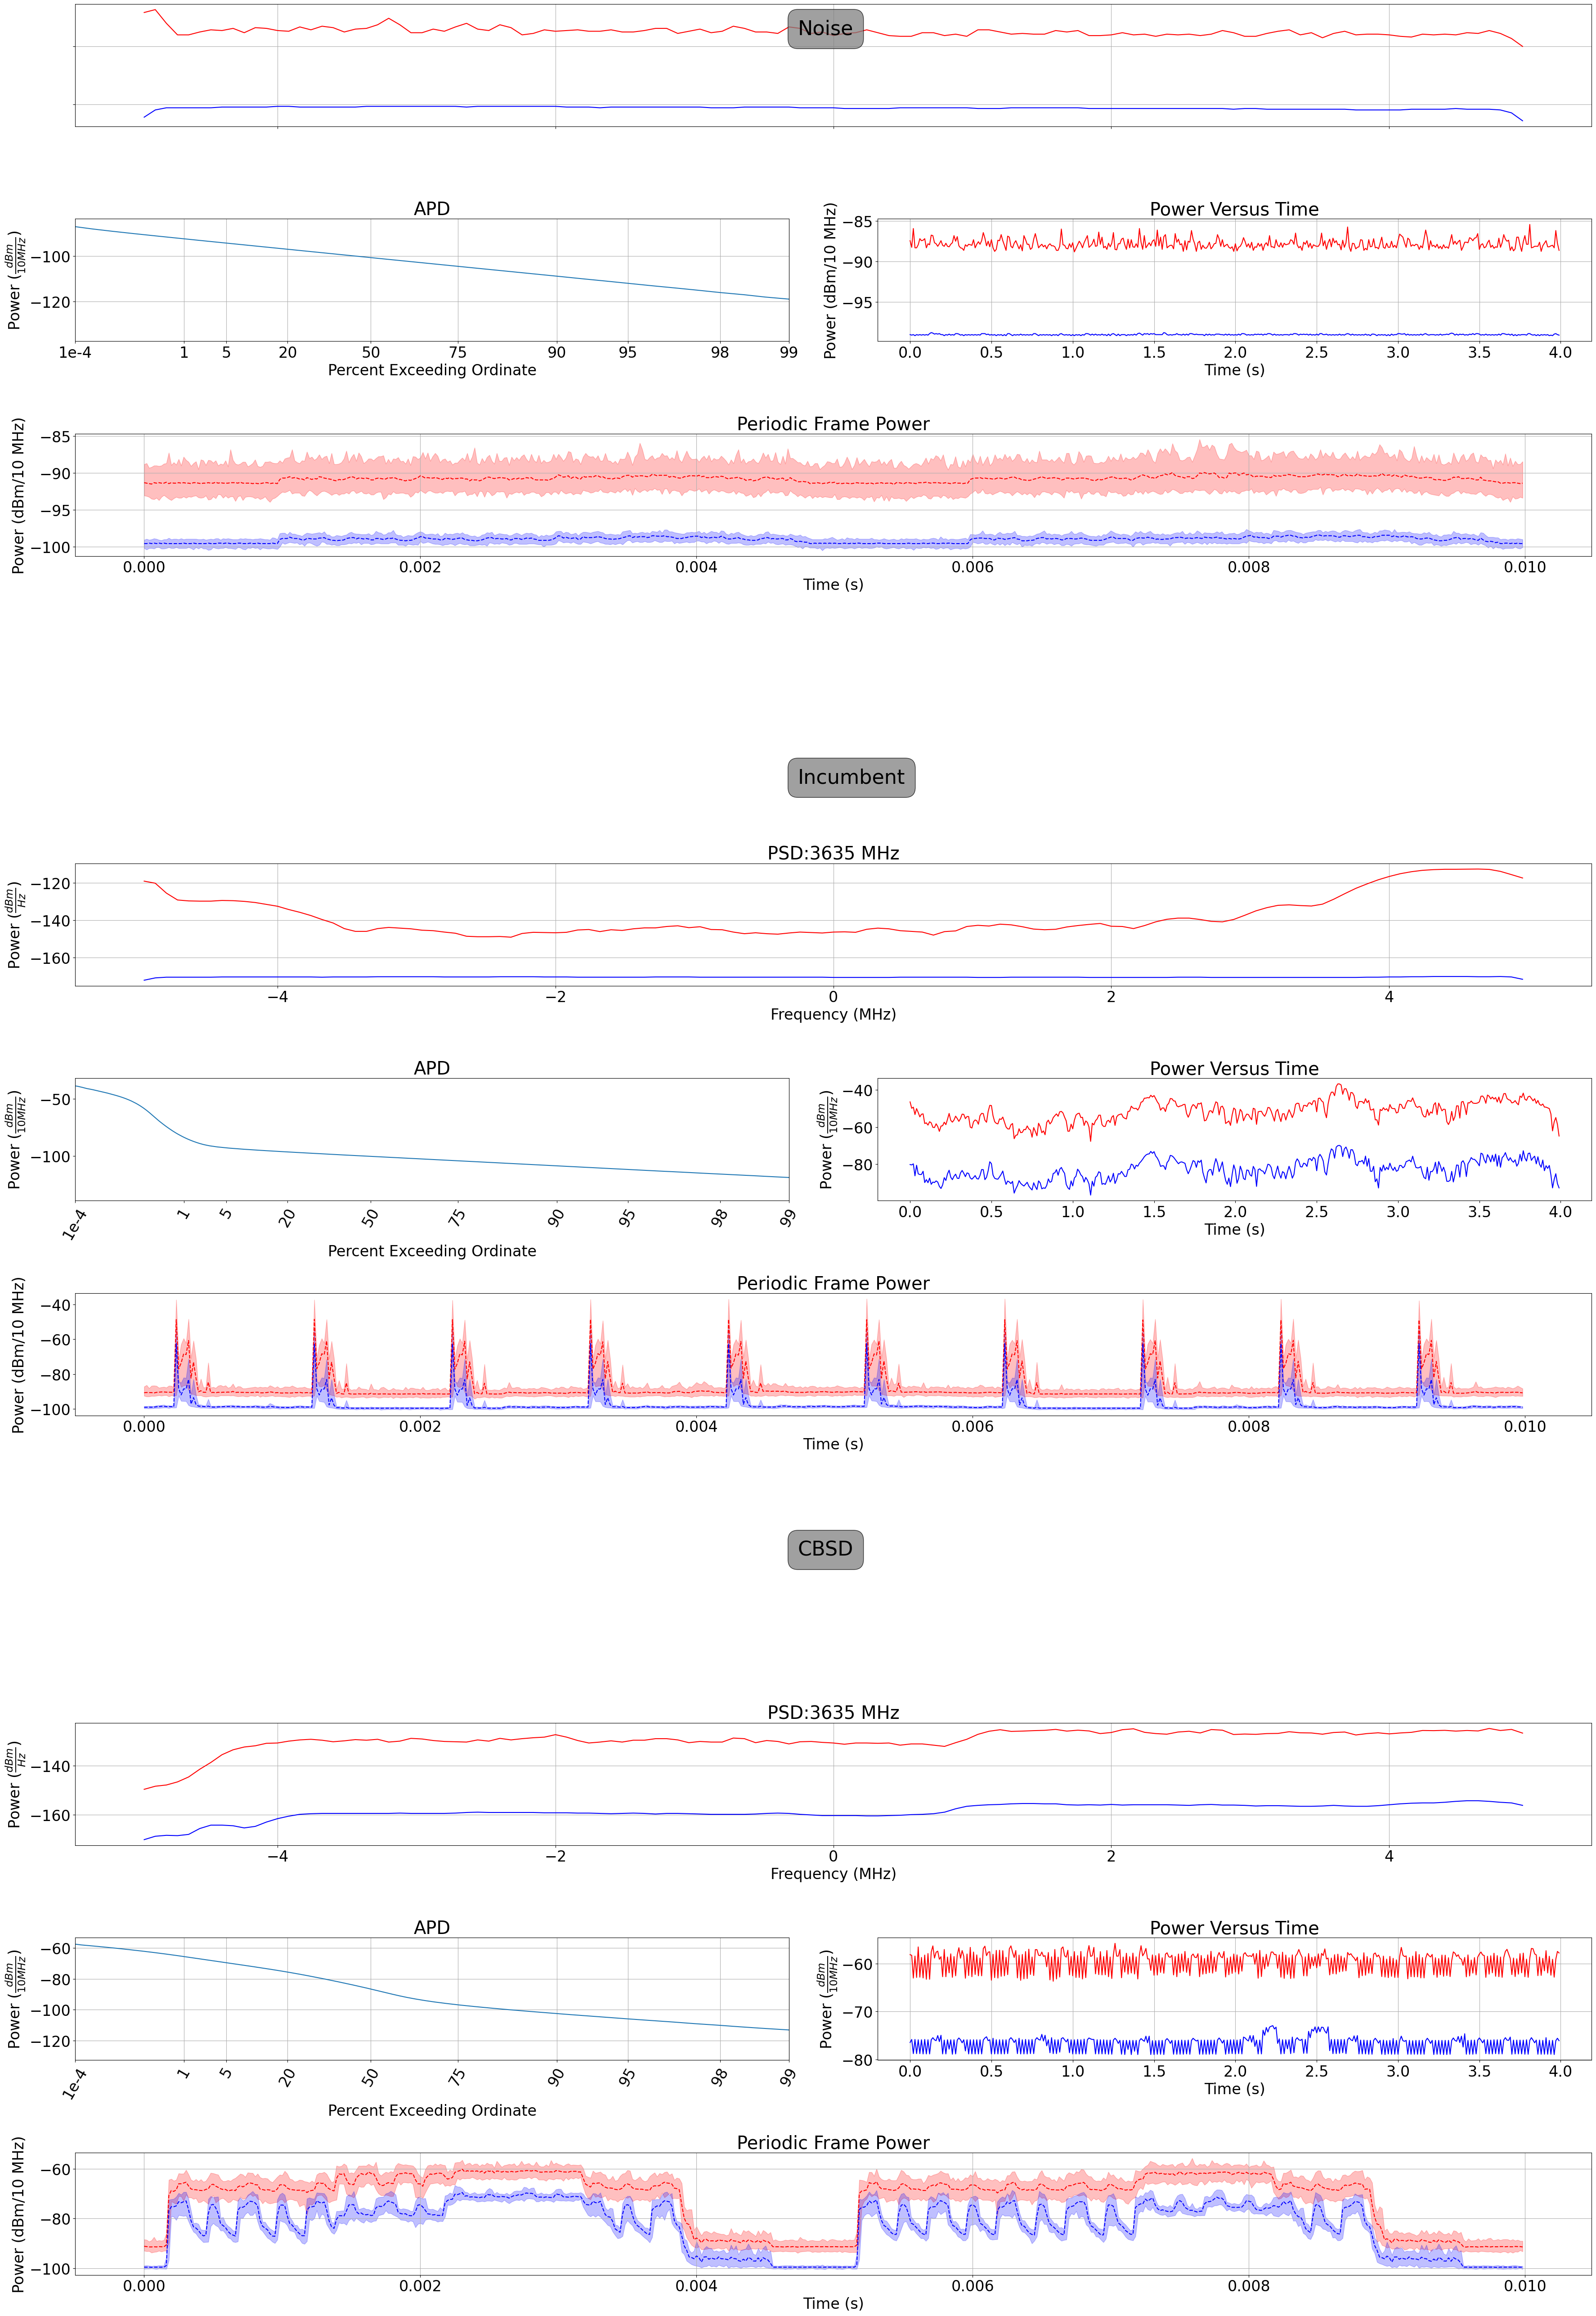

In [142]:

plt.rcParams.update({"font.size":24})
figure = plt.figure(figsize=(72/2,52))
# Setup Gridspec
gs = matplotlib.gridspec.GridSpec(11,4)    # Bottom margin
##########################################
# psd_max_ax = figure.add_subplot(gs[:,0:2])
# psd_median_ax = figure.add_subplot(gs[:,2:4],sharex=psd_max_ax,sharey=psd_max_ax)
# pfp_ax = figure.add_subplot(gs[:,4],sharey=psd_max_ax)
#########################################
# noise
psd_summary_1 = figure.add_subplot(gs[0,0:])
apd_summary_1 = figure.add_subplot(gs[1,0:2])
pvt_summary_1 = figure.add_subplot(gs[1,2:])
pfp_summary_1 = figure.add_subplot(gs[2:3,0:])
##########################################
# incumbent
psd_summary_2 = figure.add_subplot(gs[4,0:])
apd_summary_2 = figure.add_subplot(gs[5,0:2])
pvt_summary_2 = figure.add_subplot(gs[5,2:])
pfp_summary_2 = figure.add_subplot(gs[6:7,0:])
##############################################
# cbsd
psd_summary_3 = figure.add_subplot(gs[8,0:])
apd_summary_3 = figure.add_subplot(gs[9,0:2])
pvt_summary_3 = figure.add_subplot(gs[9,2:])
pfp_summary_3 = figure.add_subplot(gs[10:,0:])

# ###############################################
# # Max PSD Axis
# colormesh = psd_max_ax.pcolormesh(1e-6*max_psd.columns.astype(float),max_psd.index,max_psd,cmap="hot")
# psd_max_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
# psd_max_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
# psd_max_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# psd_max_ax.set_ylim([start_time,stop_time])
# psd_max_ax.set_xlim([start_frequency,stop_frequency])
# psd_max_ax.set_title("Max PSD")
# psd_max_ax.axhline(cbsd_time,color = "k",linestyle="dashed",linewidth=4)
# psd_max_ax.axhline(noise_time,color = "k",linestyle="dashed",linewidth=4)
# psd_max_ax.axhline(incumbent_time,color = "k",linestyle="dashed",linewidth=4)
# psd_max_ax.tick_params("x",labelbottom=True,rotation=60)
# psd_max_ax.set_ylabel("Time (UTC)")
# psd_max_ax.set_xlabel("Frequency (MHz)")
# ##############################################
# # Median PSD Axis
# colormesh = psd_median_ax.pcolormesh(1e-6*median_psd.columns.astype(float),median_psd.index,median_psd)
# psd_median_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
# psd_median_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
# psd_median_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# psd_median_ax.set_ylim([start_time,stop_time])
# psd_median_ax.set_xlim([start_frequency,stop_frequency])
# psd_median_ax.set_title("Median PSD")
# psd_median_ax.axhline(cbsd_time,color = "k",linestyle="dashed",linewidth=4)
# psd_median_ax.axhline(noise_time,color = "k",linestyle="dashed",linewidth=4)
# psd_median_ax.axhline(incumbent_time,color = "k",linestyle="dashed",linewidth=4)
# psd_median_ax.tick_params("x",labelbottom=True,rotation=60)
# psd_median_ax.tick_params("y",labelleft=False)
# psd_median_ax.set_xlabel("Frequency (MHz)")
# ###################################################
# # PFP Axis
# x_axis = np.linspace(0,10,len(pfp_peak_max.columns))
# colormesh = pfp_ax.pcolormesh(x_axis,pfp_peak_max.index,pfp_peak_max,cmap='bone',
#                             vmin=np.min(pfp_peak_max.values),vmax=np.max(pfp_peak_max.values))
# pfp_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
# pfp_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
# pfp_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# pfp_ax.tick_params("y",labelleft=False)
# pfp_ax.axhline(cbsd_time,color = "w",linestyle="dashed",linewidth=4)
# pfp_ax.axhline(noise_time,color = "w",linestyle="dashed",linewidth=4)
# pfp_ax.axhline(incumbent_time,color = "w",linestyle="dashed",linewidth=4)
# pfp_ax.set_title(f"PSD \nPeak-Max\n{10**-6*channel:3.0f} MHz")
# pfp_ax.set_xlabel("Time (ms)")

# ##########################################################
# Noise Single Plots
# Noise PSD
psd_x,psd_max = noise_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="max", detector=None)
psd_x,psd_median =  noise_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="median", detector=None)
psd_summary_1.plot(10**-6*psd_x,psd_max,color='r')
psd_summary_1.plot(10**-6*psd_x,psd_median,color='b')
psd_summary_1.grid()
# psd_summary_1.set_xlabel("Frequency (MHz)")
# psd_summary_1.set_ylabel(r"Power ($\frac{dBm}{Hz}$)")
# psd_summary_1.set_title(f"PSD:{10**-6*channel:3.0f} MHz")
psd_summary_1.tick_params("x",labelbottom=False,rotation=60)
psd_summary_1.tick_params("y",labelleft=False,rotation=60)
###############
# Noise APD
# Setup APD Plot
x,y = noise_single.get_xy_data(data_product='apd',channel = channel)
# one solution is to create a new series, swapping the axis for the channel data:
apd = pd.Series(y,index = x)
# plot setup: define x-axis ticks
# note: this configuration results in some data not being displayed
# at the highest and lowest probabilities. Adjust here or in
# the "ax.set_xlim" call to change this, if desired.
xtick_labels = [
    "1e-4", "1", "5", "20",
    "50","75","90", "95", "98", "99", #"99.9",
]
ptick_values = np.array([float(x) / 100. for x in xtick_labels])
x_origin = 10.0 * np.log10(-np.log(ptick_values[0]))
# Map p value ticks to x values
xtick = x_origin - 10.0 * np.log10(-np.log(ptick_values))
# Map p values to x axis, dealing with NaNs
p = np.where(apd.index != 0, apd.index, np.nan)
logp = np.where(np.log(p) != 0, np.log(p), np.nan)
x = x_origin - 10.0 * np.log10(-logp)
apd_summary_1.plot(x, apd.values)
apd_summary_1.set_xticks(xtick, xtick_labels)
apd_summary_1.set_xlim(xtick.min(), xtick.max())
apd_summary_1.set_xlabel("Percent Exceeding Ordinate")
apd_summary_1.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)")
apd_summary_1.set_title("APD")
# apd_summary_1.tick_params("x",labelbottom=False,rotation=60)
# apd_summary_1.tick_params("y",labelleft=False,rotation=60)
apd_summary_1.grid()
###################
# Noise PVT
x_pvt,pvt_max =  noise_single.get_xy_data(data_product='pvt',channel = channel,detector="maximum")
x_pvt,pvt_rms =  noise_single.get_xy_data(data_product='pvt',channel = channel,detector="rms")
pvt_summary_1.plot(x_pvt,pvt_max,color='r',alpha=1,linestyle="solid",label="Maximum")
pvt_summary_1.plot(x_pvt,pvt_rms,color='b',alpha=1,linestyle="solid",label="Mean")
pvt_summary_1.set_xlabel("Time (s)")
pvt_summary_1.set_ylabel("Power (dBm/10 MHz)") 
pvt_summary_1.set_title("Power Versus Time")
# pvt_summary_1.tick_params("x",labelbottom=False,rotation=60)
# pvt_summary_1.tick_params("y",labelleft=False,rotation=60)
pvt_summary_1.grid()
###################
# Noise PFP
x_pfp,peak_max = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="peak")
x_pfp,peak_mean = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="peak")              
x_pfp,peak_min = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="peak")              
x_pfp,rms_max = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="rms")
x_pfp,rms_mean = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="rms")              
x_pfp,rms_min = noise_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="rms")   
pfp_summary_1.plot(x_pfp,peak_mean,color='r',alpha=1,linestyle="dashed",label="Peak")
pfp_summary_1.fill_between(x_pfp,peak_min,peak_max,color='r',alpha=.25)   
pfp_summary_1.plot(x_pfp,rms_mean,color='b',alpha=1,linestyle="dashed",label="RMS")
pfp_summary_1.fill_between(x_pfp,rms_min,rms_max,color='b',alpha=.25)  
pfp_summary_1.set_xlabel("Time (s)")
pfp_summary_1.set_ylabel("Power (dBm/10 MHz)")
pfp_summary_1.set_title("Periodic Frame Power")
# pfp_summary_1.tick_params("x",labelbottom=False,rotation=60)
# pfp_summary_1.tick_params("y",labelleft=False,rotation=60)
pfp_summary_1.grid()
#######################################################
#######################################################
# Incumbent Single Plots
# Incumbent PSD 
psd_x,psd_max = incumbent_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="max", detector=None)
psd_x,psd_median =  incumbent_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="median", detector=None)
psd_summary_2.plot(10**-6*psd_x,psd_max,color='r')
psd_summary_2.plot(10**-6*psd_x,psd_median,color='b')
psd_summary_2.grid()
psd_summary_2.set_xlabel("Frequency (MHz)")
psd_summary_2.set_ylabel(r"Power ($\frac{dBm}{Hz}$)")
psd_summary_2.set_title(f"PSD:{10**-6*channel:3.0f} MHz")
####################
# Incumbent APD
# Setup APD Plot
x,y = incumbent_single.get_xy_data(data_product='apd',channel = channel)
# one solution is to create a new series, swapping the axis for the channel data:
apd = pd.Series(y,index = x)
# plot setup: define x-axis ticks
# note: this configuration results in some data not being displayed
# at the highest and lowest probabilities. Adjust here or in
# the "ax.set_xlim" call to change this, if desired.
xtick_labels = [
    "1e-4", "1", "5", "20",
    "50","75","90", "95", "98", "99", #"99.9",
]
ptick_values = np.array([float(x) / 100. for x in xtick_labels])
x_origin = 10.0 * np.log10(-np.log(ptick_values[0]))
# Map p value ticks to x values
xtick = x_origin - 10.0 * np.log10(-np.log(ptick_values))
# Map p values to x axis, dealing with NaNs
p = np.where(apd.index != 0, apd.index, np.nan)
logp = np.where(np.log(p) != 0, np.log(p), np.nan)
x = x_origin - 10.0 * np.log10(-logp)
apd_summary_2.plot(x, apd.values)
apd_summary_2.set_xticks(xtick, xtick_labels)
apd_summary_2.set_xlim(xtick.min(), xtick.max())
apd_summary_2.set_xlabel("Percent Exceeding Ordinate")
apd_summary_2.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)")
apd_summary_2.set_title("APD")
apd_summary_2.tick_params("x",labelbottom=True,rotation=60)

###################
# incumbent PVT
x_pvt,pvt_max =  incumbent_single.get_xy_data(data_product='pvt',channel = channel,detector="maximum")
x_pvt,pvt_rms =  incumbent_single.get_xy_data(data_product='pvt',channel = channel,detector="rms")
pvt_summary_2.plot(x_pvt,pvt_max,color='r',alpha=1,linestyle="solid",label="Maximum")
pvt_summary_2.plot(x_pvt,pvt_rms,color='b',alpha=1,linestyle="solid",label="Mean")
pvt_summary_2.set_xlabel("Time (s)")
pvt_summary_2.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)") 
pvt_summary_2.set_title("Power Versus Time")
###################
# incumbent PFP
x_pfp,peak_max = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="peak")
x_pfp,peak_mean = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="peak")              
x_pfp,peak_min = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="peak")              
x_pfp,rms_max = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="rms")
x_pfp,rms_mean = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="rms")              
x_pfp,rms_min = incumbent_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="rms")   
pfp_summary_2.plot(x_pfp,peak_mean,color='r',alpha=1,linestyle="dashed",label="Peak")
pfp_summary_2.fill_between(x_pfp,peak_min,peak_max,color='r',alpha=.25)   
pfp_summary_2.plot(x_pfp,rms_mean,color='b',alpha=1,linestyle="dashed",label="RMS")
pfp_summary_2.fill_between(x_pfp,rms_min,rms_max,color='b',alpha=.25)  
pfp_summary_2.set_xlabel("Time (s)")
pfp_summary_2.set_ylabel("Power (dBm/10 MHz)")
pfp_summary_2.set_title("Periodic Frame Power")

########################################################
#########################################################
# CBSD Single Plots
# CBSD PSD 
psd_x,psd_max = cbsd_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="max", detector=None)
psd_x,psd_median =  cbsd_single.get_xy_data( channel=channel, data_product='psd', capture_statistic="median", detector=None)
psd_summary_3.plot(10**-6*psd_x,psd_max,color='r')
psd_summary_3.plot(10**-6*psd_x,psd_median,color='b')
psd_summary_3.grid()
psd_summary_3.set_xlabel("Frequency (MHz)")
psd_summary_3.set_ylabel(r"Power ($\frac{dBm}{Hz}$)")
psd_summary_3.set_title(f"PSD:{10**-6*channel:3.0f} MHz")
############
# CBSD APD
# Setup APD Plot
x,y = cbsd_single.get_xy_data(data_product='apd',channel = channel)
# one solution is to create a new series, swapping the axis for the channel data:
apd = pd.Series(y,index = x)
# plot setup: define x-axis ticks
# note: this configuration results in some data not being displayed
# at the highest and lowest probabilities. Adjust here or in
# the "ax.set_xlim" call to change this, if desired.
xtick_labels = [
    "1e-4", "1", "5", "20",
    "50","75","90", "95", "98", "99", #"99.9",
]
ptick_values = np.array([float(x) / 100. for x in xtick_labels])
x_origin = 10.0 * np.log10(-np.log(ptick_values[0]))
# Map p value ticks to x values
xtick = x_origin - 10.0 * np.log10(-np.log(ptick_values))
# Map p values to x axis, dealing with NaNs
p = np.where(apd.index != 0, apd.index, np.nan)
logp = np.where(np.log(p) != 0, np.log(p), np.nan)
x = x_origin - 10.0 * np.log10(-logp)
apd_summary_3.plot(x, apd.values)
apd_summary_3.set_xticks(xtick, xtick_labels)
apd_summary_3.set_xlim(xtick.min(), xtick.max())
apd_summary_3.set_xlabel("Percent Exceeding Ordinate")
apd_summary_3.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)")
apd_summary_3.set_title("APD")
apd_summary_3.tick_params("x",labelbottom=True,rotation=60)
apd_summary_3.grid()
###################
# incumbent PVT
x_pvt,pvt_max =  cbsd_single.get_xy_data(data_product='pvt',channel = channel,detector="maximum")
x_pvt,pvt_rms =  cbsd_single.get_xy_data(data_product='pvt',channel = channel,detector="rms")
pvt_summary_3.plot(x_pvt,pvt_max,color='r',alpha=1,linestyle="solid",label="Maximum")
pvt_summary_3.plot(x_pvt,pvt_rms,color='b',alpha=1,linestyle="solid",label="Mean")
pvt_summary_3.set_xlabel("Time (s)")
pvt_summary_3.set_ylabel(r"Power ($\frac{dBm}{10 MHz}$)") 
pvt_summary_3.set_title("Power Versus Time")
pvt_summary_3.grid()
###################
# cbsd PFP
x_pfp,peak_max = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="peak")
x_pfp,peak_mean = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="peak")              
x_pfp,peak_min = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="peak")              
x_pfp,rms_max = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="max",detector="rms")
x_pfp,rms_mean = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="mean",detector="rms")              
x_pfp,rms_min = cbsd_single.get_xy_data(data_product='pfp',channel = channel,capture_statistic="min",detector="rms")   
pfp_summary_3.plot(x_pfp,peak_mean,color='r',alpha=1,linestyle="dashed",label="Peak")
pfp_summary_3.fill_between(x_pfp,peak_min,peak_max,color='r',alpha=.25)   
pfp_summary_3.plot(x_pfp,rms_mean,color='b',alpha=1,linestyle="dashed",label="RMS")
pfp_summary_3.fill_between(x_pfp,rms_min,rms_max,color='b',alpha=.25)  
pfp_summary_3.set_xlabel("Time (s)")
pfp_summary_3.set_ylabel("Power (dBm/10 MHz)")
pfp_summary_3.set_title("Periodic Frame Power")
pfp_summary_3.grid()

figure.text(.5,.98,"Noise",fontsize=32,bbox=dict(
        facecolor='grey',   # Background color
        edgecolor='k',    # Border color
        boxstyle='round,pad=0.5', # Box shape and padding
        alpha=0.75            # Transparency (0 to 1)
    ))
figure.text(.5,.66,"Incumbent",fontsize=32,bbox=dict(
        facecolor='grey',   # Background color
        edgecolor='k',    # Border color
        boxstyle='round,pad=0.5', # Box shape and padding
        alpha=0.75             # Transparency (0 to 1)
    ))
figure.text(.5,.33,"CBSD",fontsize=32,bbox=dict(
        facecolor='grey',   # Background color
        edgecolor='k',    # Border color
        boxstyle='round,pad=0.5', # Box shape and padding
        alpha=0.75             # Transparency (0 to 1)
    ))
########################################################
plt.tight_layout()

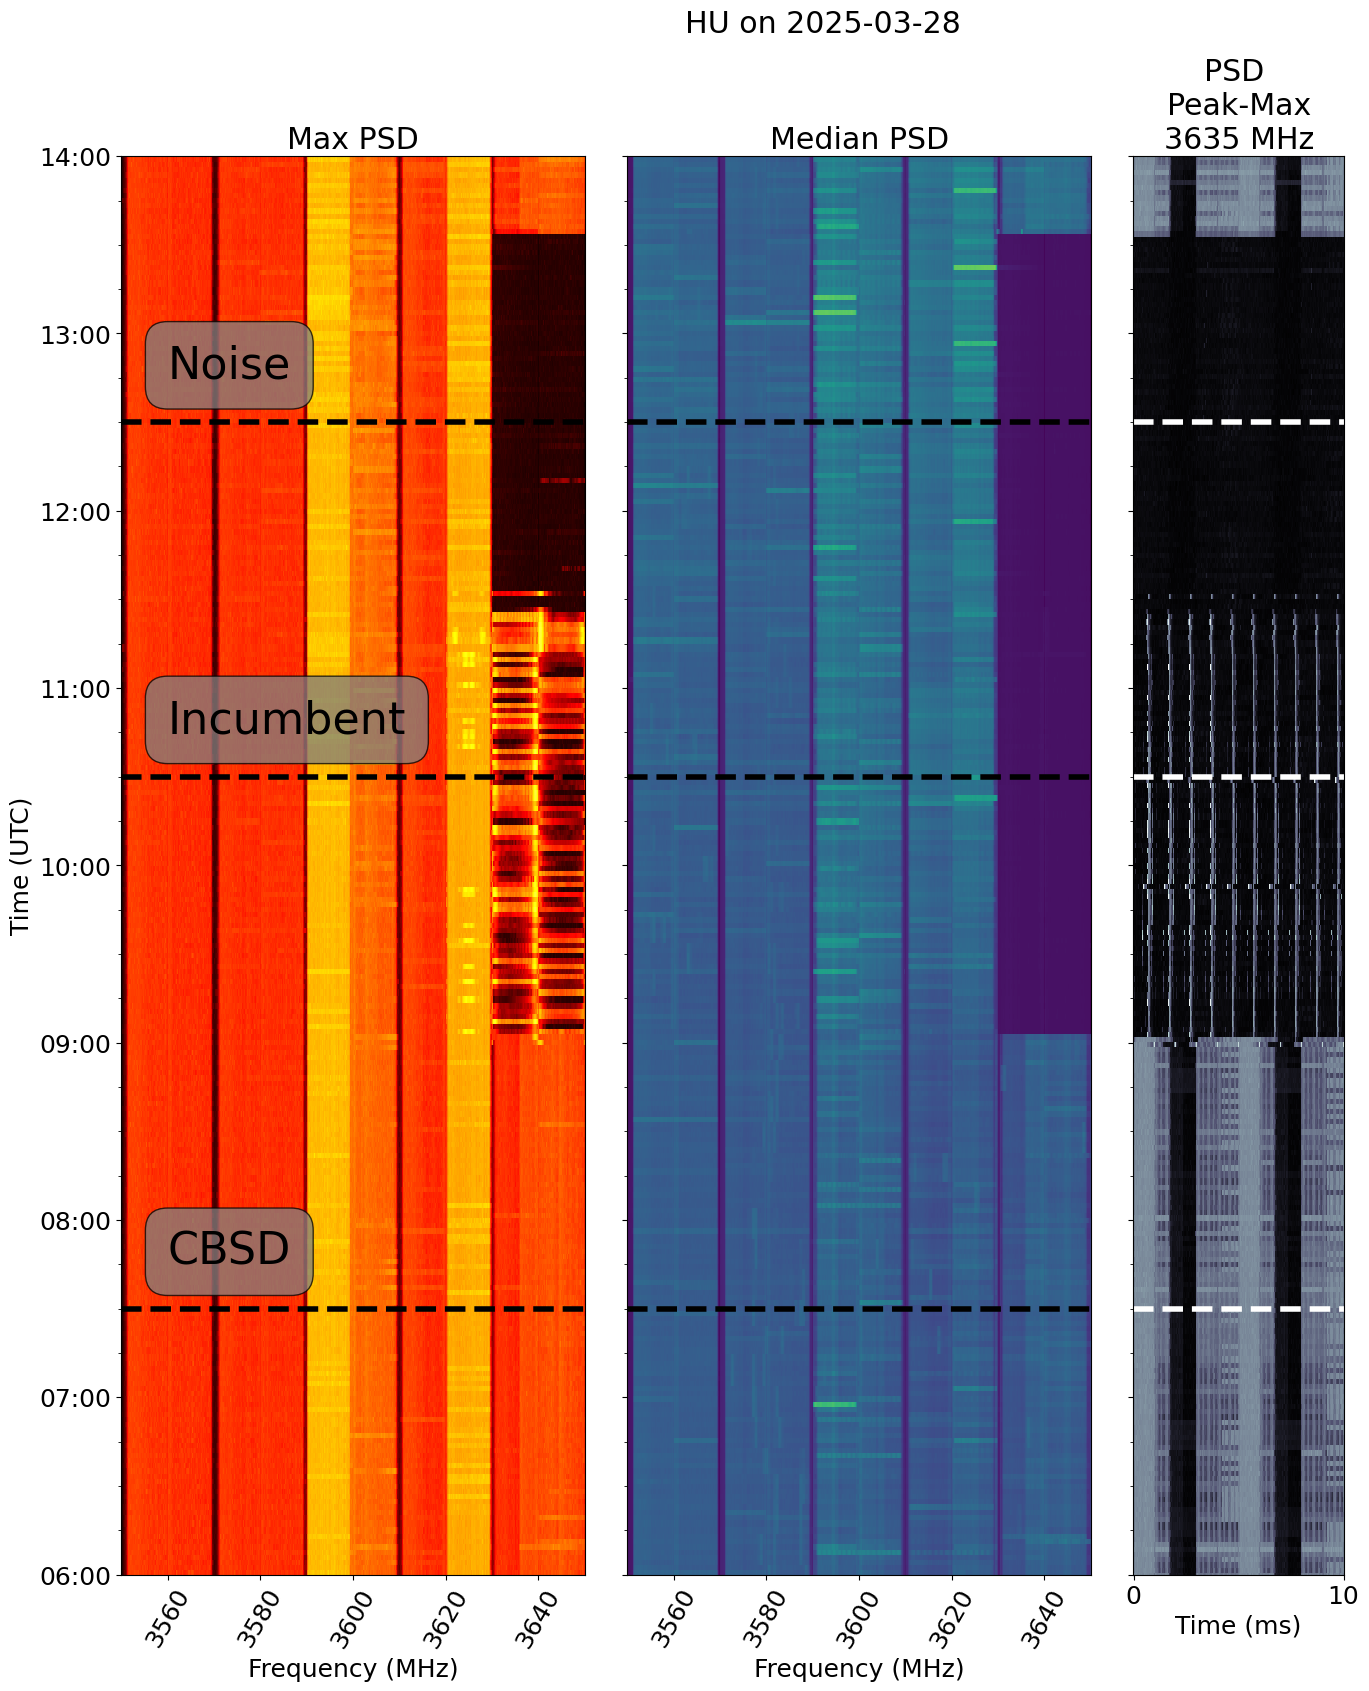

In [132]:

plt.rcParams.update({"font.size":18})
figure = plt.figure(figsize=(72/3,52/3))
# Setup Gridspec
gs = matplotlib.gridspec.GridSpec(8,9)    
##########################################
psd_max_ax = figure.add_subplot(gs[:,0:2])
psd_median_ax = figure.add_subplot(gs[:,2:4],sharex=psd_max_ax,sharey=psd_max_ax)
pfp_ax = figure.add_subplot(gs[:,4],sharey=psd_max_ax)
#########################################
# # noise
# psd_summary_1 = figure.add_subplot(gs[0,5:])
# apd_summary_1 = figure.add_subplot(gs[1,5:6])
# pvt_summary_1 = figure.add_subplot(gs[1,6:])
# pfp_summary_1 = figure.add_subplot(gs[2:3,5:])
# ##########################################
# # incumbent
# psd_summary_2 = figure.add_subplot(gs[4,5:])
# apd_summary_2 = figure.add_subplot(gs[5,5:6])
# pvt_summary_2 = figure.add_subplot(gs[5,6:])
# pfp_summary_2 = figure.add_subplot(gs[6:7,5:])
# ##############################################
# # cbsd
# psd_summary_3 = figure.add_subplot(gs[8,5:])
# apd_summary_3 = figure.add_subplot(gs[9,5:6])
# pvt_summary_3 = figure.add_subplot(gs[9,6:])
# pfp_summary_3 = figure.add_subplot(gs[10:,5:])

###############################################
# Max PSD Axis
colormesh = psd_max_ax.pcolormesh(1e-6*max_psd.columns.astype(float),max_psd.index,max_psd,cmap="hot")
psd_max_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
psd_max_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
psd_max_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
psd_max_ax.set_ylim([start_time,stop_time])
psd_max_ax.set_xlim([start_frequency,stop_frequency])
psd_max_ax.set_title("Max PSD")
psd_max_ax.axhline(cbsd_time,color = "k",linestyle="dashed",linewidth=4)
psd_max_ax.axhline(noise_time,color = "k",linestyle="dashed",linewidth=4)
psd_max_ax.axhline(incumbent_time,color = "k",linestyle="dashed",linewidth=4)
psd_max_ax.tick_params("x",labelbottom=True,rotation=60)
psd_max_ax.set_ylabel("Time (UTC)")
psd_max_ax.set_xlabel("Frequency (MHz)")
psd_max_ax.text(start_frequency+10,noise_time+pd.Timedelta(15, unit="m"),"Noise",fontsize=32,bbox=dict(
        facecolor='grey',   # Background color
        edgecolor='k',    # Border color
        boxstyle='round,pad=0.5', # Box shape and padding
        alpha=0.75            # Transparency (0 to 1)
    ))
psd_max_ax.text(start_frequency+10,incumbent_time+pd.Timedelta(15, unit="m"),"Incumbent",fontsize=32,bbox=dict(
        facecolor='grey',   # Background color
        edgecolor='k',    # Border color
        boxstyle='round,pad=0.5', # Box shape and padding
        alpha=0.75             # Transparency (0 to 1)
    ))
psd_max_ax.text(start_frequency+10,cbsd_time+pd.Timedelta(15, unit="m"),"CBSD",fontsize=32,bbox=dict(
        facecolor='grey',   # Background color
        edgecolor='k',    # Border color
        boxstyle='round,pad=0.5', # Box shape and padding
        alpha=0.75             # Transparency (0 to 1)
    ))
##############################################
# Median PSD Axis
colormesh = psd_median_ax.pcolormesh(1e-6*median_psd.columns.astype(float),median_psd.index,median_psd)
psd_median_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
psd_median_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
psd_median_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
psd_median_ax.set_ylim([start_time,stop_time])
psd_median_ax.set_xlim([start_frequency,stop_frequency])
psd_median_ax.set_title("Median PSD")
psd_median_ax.axhline(cbsd_time,color = "k",linestyle="dashed",linewidth=4)
psd_median_ax.axhline(noise_time,color = "k",linestyle="dashed",linewidth=4)
psd_median_ax.axhline(incumbent_time,color = "k",linestyle="dashed",linewidth=4)
psd_median_ax.tick_params("x",labelbottom=True,rotation=60)
psd_median_ax.tick_params("y",labelleft=False)
psd_median_ax.set_xlabel("Frequency (MHz)")
###################################################
# PFP Axis
x_axis = np.linspace(0,10,len(pfp_peak_max.columns))
colormesh = pfp_ax.pcolormesh(x_axis,pfp_peak_max.index,pfp_peak_max,cmap='bone',
                            vmin=np.min(pfp_peak_max.values),vmax=np.max(pfp_peak_max.values))
pfp_ax.yaxis.set_minor_locator(mdates.MinuteLocator(interval = 15))
pfp_ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))
pfp_ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
pfp_ax.tick_params("y",labelleft=False)
pfp_ax.axhline(cbsd_time,color = "w",linestyle="dashed",linewidth=4)
pfp_ax.axhline(noise_time,color = "w",linestyle="dashed",linewidth=4)
pfp_ax.axhline(incumbent_time,color = "w",linestyle="dashed",linewidth=4)
pfp_ax.set_title(f"PSD \nPeak-Max\n{10**-6*channel:3.0f} MHz")
pfp_ax.set_xlabel("Time (ms)")

figure.suptitle("HU on 2025-03-28",x=.35)
########################################################
plt.tight_layout()

In [114]:
cbsd_single_plotter = DataProductPlotter(data = cbsd_single)

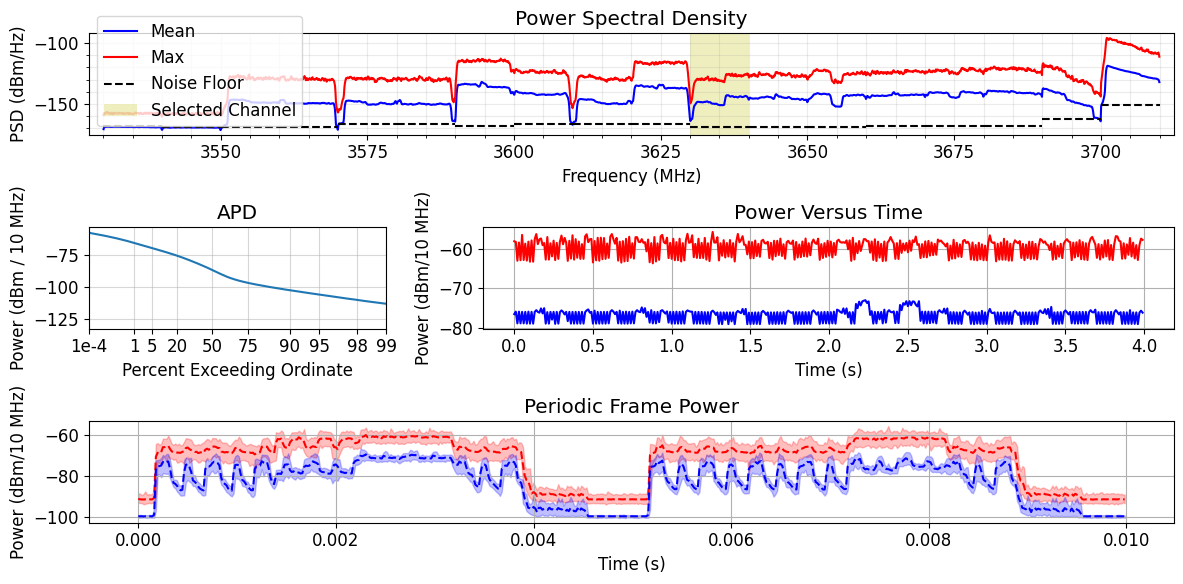

In [116]:
plt.rcParams.update({"font.size":12})
cbsd_single_plotter.plot_channel_summary(channel=channel)

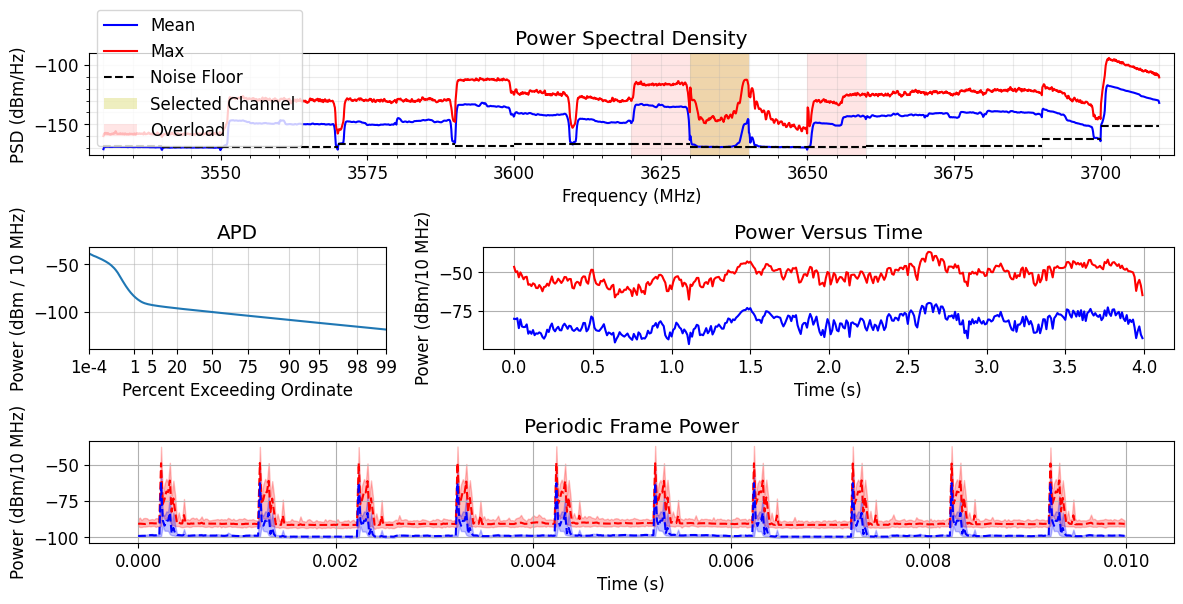

In [117]:
incumbent_single_plotter = DataProductPlotter(data = incumbent_single)
plt.rcParams.update({"font.size":12})
incumbent_single_plotter.plot_channel_summary(channel=channel)